# 05 — API, dashboard y demo de inferencia

Este notebook resume cómo se comunica el dashboard con la API, el pipeline y los modelos.

In [1]:

from pathlib import Path
import json
import os
import subprocess
import textwrap
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto localizando docker-compose.yml."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "docker-compose.yml").exists():
            return candidate
    # Si el notebook se ejecuta desde notebooks/ antes de abrir el repo correctamente.
    return start


ROOT = find_project_root()
print(f"ROOT = {ROOT}")


def read_json(path: Path, default=None):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_env(path: Path) -> dict:
    env = {}
    path = Path(path)
    if not path.exists():
        return env
    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        env[k.strip()] = v.strip().strip('"').strip("'")
    return env


def run_cmd(cmd: str, timeout: int = 60) -> str:
    """Ejecuta un comando shell y devuelve stdout/stderr como texto."""
    print(f"$ {cmd}")
    try:
        result = subprocess.run(
            cmd,
            shell=True,
            cwd=ROOT,
            text=True,
            capture_output=True,
            timeout=timeout,
        )
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        print(f"exit_code={result.returncode}")
        return (result.stdout or "") + (result.stderr or "")
    except Exception as exc:
        print(f"[error] {exc}")
        return str(exc)


def show_bar(series, title: str, ylabel: str = "valor"):
    ax = pd.Series(series).plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


ROOT = c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943


## 1. Endpoints principales

| Endpoint | Servicio | Función |
|---|---|---|
| `GET /health` | api | Estado de API. |
| `GET /patients` | api | Listado de pacientes. |
| `GET /patients/{pseudo_id}` | api | Ficha individual. |
| `GET /patients/{pseudo_id}/pdf` | api | PDF clínico. |
| `POST /patients` | api | Formulario individual. |
| `POST /batch-runs` | api | CSV batch. |
| `GET /batch-runs/{run_id}/events` | api | Eventos de ejecución. |
| `GET /healthz` | ml-inference | Estado modelo radiografías. |
| `POST /predict` | ml-inference | Clasificación radiografía. |

In [ ]:
env = read_env(ROOT/".env")
api_port = env.get("API_PORT", "8005")
dash_port = env.get("DASHBOARD_PORT", "8502")

print(f"Dashboard: http://localhost:{dash_port}")
print(f"API host probable: http://localhost:{api_port}")
print("ml-inference dentro de Docker: http://ml-inference:8001")


## 2. Healthchecks

Comandos recomendados:

```powershell
docker compose ps
curl.exe -s http://localhost:<API_PORT>/health
docker compose exec ml-inference curl -s http://localhost:8001/healthz
docker compose exec ml-triage curl -s http://localhost:8002/health
```

In [ ]:
# Puedes descomentar si quieres ejecutarlo desde Jupyter.
# run_cmd("docker compose ps", timeout=30)
# run_cmd("docker compose exec ml-inference curl -s http://localhost:8001/healthz", timeout=30)


## 3. Demo dashboard

Abrir:

```text
http://localhost:8502
```

Pestañas:

- `Pacientes`: listado, filtro y PDF.
- `Triaje`: formulario individual y lote CSV.
- `Radiografías`: subida de imagen y llamada a `ml-inference`.
- `Estado`: estado básico del backend.

## 4. Demo radiografías

Comandos reales de prueba:

```powershell
docker compose exec ml-inference sh -lc "curl -s -X POST http://localhost:8001/predict -F 'file=@/app/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png'"

docker compose exec ml-inference sh -lc "curl -s -X POST http://localhost:8001/predict -F 'file=@/app/COVID-19_Radiography_Dataset/Normal/images/Normal-1.png'"

docker compose exec ml-inference sh -lc "curl -s -X POST http://localhost:8001/predict -F 'file=@/app/COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1.png'"

docker compose exec ml-inference sh -lc "curl -s -X POST http://localhost:8001/predict -F 'file=@/app/COVID-19_Radiography_Dataset/Lung_Opacity/images/Lung_Opacity-1.png'"
```

In [2]:
# Resultados de ejemplo reales obtenidos con EfficientNet-B0 activo.
examples = pd.DataFrame([
    {"imagen": "COVID-1.png", "predicted_class": "COVID-19", "Sana": 0.0007, "Neumonía": 0.3868, "COVID-19": 0.6125},
    {"imagen": "Normal-1.png", "predicted_class": "Sana", "Sana": 0.9984, "Neumonía": 0.0016, "COVID-19": 0.0000},
    {"imagen": "Viral Pneumonia-1.png", "predicted_class": "Neumonía", "Sana": 0.3120, "Neumonía": 0.6875, "COVID-19": 0.0005},
    {"imagen": "Lung_Opacity-1.png", "predicted_class": "Neumonía", "Sana": 0.1307, "Neumonía": 0.8656, "COVID-19": 0.0037},
])
examples


,imagen,predicted_class,Sana,Neumonía,COVID-19
0,COVID-1.png,COVID-19,0.0007,0.3868,0.6125
1,Normal-1.png,Sana,0.9984,0.0016,0.0000
2,Viral Pneumonia-1.png,Neumonía,0.3120,0.6875,0.0005
3,Lung_Opacity-1.png,Neumonía,0.1307,0.8656,0.0037


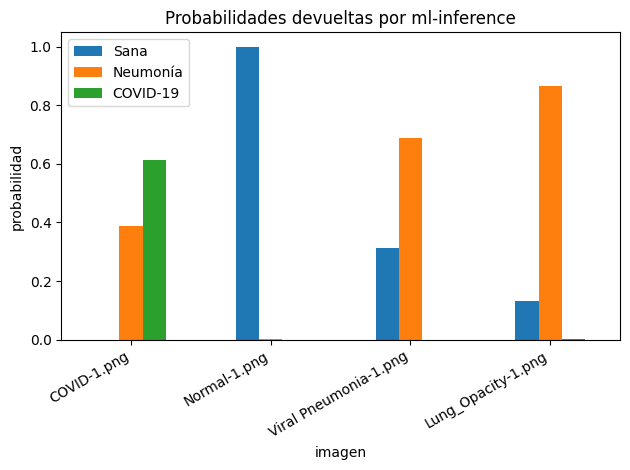

In [3]:
# Visualización de probabilidades por imagen.
plot_df = examples.set_index("imagen")[["Sana", "Neumonía", "COVID-19"]]
ax = plot_df.plot(kind="bar")
ax.set_title("Probabilidades devueltas por ml-inference")
ax.set_ylabel("probabilidad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 5. Demo batch + eventos

Ejemplo:

```powershell
docker compose exec pipeline python main.py seed --n 20 --seed 555

docker compose exec pipeline python main.py batch --key "patients/<archivo>.csv"
```

El dashboard muestra eventos del run en vivo mediante:

```text
GET /batch-runs/{run_id}/events
```

## 6. Qué demuestra esta parte

- El dashboard no contiene lógica pesada.
- La API centraliza acceso al backend.
- El pipeline procesa datos.
- Los modelos están encapsulados como servicios.
- El usuario final ve resultados comprensibles: clase, probabilidades, alerta y PDF.